<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/Reservoir_and_Power_manage_R1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import re

# =========================================================
# 1) LOAD AND PARSE DIGITAL HILL CHART FILE
# =========================================================
def parse_loka_hillchart(excel_path):
    raw = pd.read_excel(excel_path, header=0)
    raw = raw.reset_index(drop=True)

    first_col = raw.columns[0]
    hill_rows = []

    i = 0
    while i < len(raw):
        cell = str(raw.iloc[i, 0]).strip()

        # Detect block header like: NetHead_m=82.5
        m = re.match(r"NetHead_m\s*=\s*([0-9.]+)", cell)
        if m:
            net_head = float(m.group(1))

            # Next expected rows:
            # i+1 -> ActivePower_MW
            # i+2 -> Flow_m3s
            # i+3 -> Efficency
            # i+4 -> Oppening (optional)
            if i + 3 < len(raw):
                power_row = raw.iloc[i + 1, :]
                flow_row  = raw.iloc[i + 2, :]
                eta_row   = raw.iloc[i + 3, :]
                opening_row = raw.iloc[i + 4, :] if i + 4 < len(raw) else None

                for col in raw.columns[1:]:
                    power = pd.to_numeric(power_row[col], errors="coerce")
                    flow  = pd.to_numeric(flow_row[col], errors="coerce")
                    eta   = pd.to_numeric(eta_row[col], errors="coerce")
                    opening = pd.to_numeric(opening_row[col], errors="coerce") if opening_row is not None else np.nan

                    if pd.notna(power) and pd.notna(flow) and pd.notna(eta):
                        hill_rows.append({
                            "net_head_m": net_head,
                            "power_mw": float(power),
                            "flow_m3s": float(flow),
                            "eta": float(eta),
                            "opening_pct": opening if pd.notna(opening) else np.nan
                        })
            i += 5
        else:
            i += 1

    hill_df = pd.DataFrame(hill_rows).sort_values(["net_head_m", "power_mw"]).reset_index(drop=True)
    return hill_df


# =========================================================
# 2) HILL CHART INTERPOLATION FUNCTIONS
# =========================================================
def interp_by_head_and_power(hill_df, head, power, value_col):
    heads = np.sort(hill_df["net_head_m"].unique())

    if head <= heads.min():
        h1 = h2 = heads.min()
    elif head >= heads.max():
        h1 = h2 = heads.max()
    else:
        h1 = heads[heads <= head].max()
        h2 = heads[heads >= head].min()

    df1 = hill_df[hill_df["net_head_m"] == h1].sort_values("power_mw")
    v1 = np.interp(power, df1["power_mw"], df1[value_col])

    if h1 == h2:
        return v1

    df2 = hill_df[hill_df["net_head_m"] == h2].sort_values("power_mw")
    v2 = np.interp(power, df2["power_mw"], df2[value_col])

    return np.interp(head, [h1, h2], [v1, v2])


def flow_from_power_head(hill_df, power_mw, net_head_m):
    return interp_by_head_and_power(hill_df, net_head_m, power_mw, "flow_m3s")


def eta_from_power_head(hill_df, power_mw, net_head_m):
    return interp_by_head_and_power(hill_df, net_head_m, power_mw, "eta")


def opening_from_power_head(hill_df, power_mw, net_head_m):
    if "opening_pct" not in hill_df.columns or hill_df["opening_pct"].isna().all():
        return np.nan
    return interp_by_head_and_power(hill_df, net_head_m, power_mw, "opening_pct")


def power_from_flow_head(hill_df, flow_m3s, net_head_m):
    candidate_powers = np.linspace(
        hill_df["power_mw"].min(),
        hill_df["power_mw"].max(),
        400
    )
    candidate_flows = np.array([
        flow_from_power_head(hill_df, p, net_head_m) for p in candidate_powers
    ])

    # Ensure monotonic interpolation direction
    sort_idx = np.argsort(candidate_flows)
    candidate_flows = candidate_flows[sort_idx]
    candidate_powers = candidate_powers[sort_idx]

    return np.interp(flow_m3s, candidate_flows, candidate_powers)


# =========================================================
# 3) LOAD WATER FILE
# =========================================================
water = pd.read_excel("Water_change.xlsx")
water.columns = [str(c).replace("\n", " ").strip() for c in water.columns]

water = water.rename(columns={
    "TARİH": "date",
    "GELEN SUYUN DEBİSİ (m3/sn)": "inflow_m3s",
    "AKTİF GÖL HACMİ  (m3)": "active_storage_m3",
    "AKTİF GÖL HACMİ (m3)": "active_storage_m3",
    "GÖLDEKİ HACİM FARKI (m3)": "storage_change_file_m3",
    "24:00 GÖL SEVİYESİ": "lake_level_24h",
    "08:00 GÖL SEVİYESİ": "lake_level_08h",
    "ÜRETİLEBİLECEK ENERJİ ( kWh)": "potential_energy_kwh",
    "ÜRETİLEBİLECEK ENERJİ (kWh)": "potential_energy_kwh",
    "DSİ BIRAKILAN SU (m3/h)": "dsi_release_m3h"
})

water["date"] = pd.to_datetime(water["date"], errors="coerce")
water = water.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

if "active_storage_m3" in water.columns:
    water["storage_change_calc_m3"] = water["active_storage_m3"].diff()
else:
    water["storage_change_calc_m3"] = np.nan

water["storage_change_m3"] = water.get("storage_change_file_m3", np.nan)
water["storage_change_m3"] = water["storage_change_m3"].fillna(water["storage_change_calc_m3"])

# optional: convert DSI release from m3/h to equivalent m3/s
if "dsi_release_m3h" in water.columns:
    water["dsi_release_m3s"] = pd.to_numeric(water["dsi_release_m3h"], errors="coerce") / 3600.0
else:
    water["dsi_release_m3s"] = 0.0


# =========================================================
# 4) LOAD NET HEAD FILE
# =========================================================
head = pd.read_excel("Net_Head.xlsx")
head.columns = [str(c).strip() for c in head.columns]

# Adjust these names if your file uses slightly different headers
head = head.rename(columns={
    "Timestamp": "timestamp",
    "Net_Head": "net_head_m",
    "Net Head": "net_head_m",
    "NET_HEAD": "net_head_m"
})

head["timestamp"] = pd.to_datetime(head["timestamp"], errors="coerce")
head["net_head_m"] = pd.to_numeric(head["net_head_m"], errors="coerce")
head = head.dropna(subset=["timestamp", "net_head_m"]).sort_values("timestamp").reset_index(drop=True)

head["date"] = head["timestamp"].dt.floor("D")

daily_head = head.groupby("date", as_index=False).agg(
    net_head_mean_m=("net_head_m", "mean"),
    net_head_min_m=("net_head_m", "min"),
    net_head_max_m=("net_head_m", "max"),
    net_head_std_m=("net_head_m", "std")
)

daily_head["head_change_m"] = daily_head["net_head_mean_m"].diff()


# =========================================================
# 5) LOAD DIGITAL HILL CHART
# =========================================================
hill_df = parse_loka_hillchart("LOKA_Digital_hillchart_extracted.xlsx")

print("Parsed hill chart:")
print(hill_df.head(15))
print("\nAvailable net head slices:", sorted(hill_df["net_head_m"].unique()))


# =========================================================
# 6) MERGE DAILY DATA
# =========================================================
df = water.merge(daily_head, on="date", how="left")

df["net_head_mean_m"] = df["net_head_mean_m"].interpolate().bfill().ffill()
df["head_change_m"] = df["head_change_m"].fillna(0.0)

# If DSI release exists, subtract it from useful inflow
df["effective_inflow_m3s"] = df["inflow_m3s"] - df["dsi_release_m3s"]
df["effective_inflow_m3s"] = df["effective_inflow_m3s"].clip(lower=0)


# =========================================================
# 7) OPTIMIZATION PARAMETERS
# =========================================================
NUM_BIG_UNITS = 3
CURRENT_MW = 111.0

MW_MIN = float(hill_df["power_mw"].min())
MW_MAX = min(136.0, float(hill_df["power_mw"].max()))

GOOD_LOW = 109.0
GOOD_HIGH = 115.0
BEST_TARGET = 120.0

STORAGE_RISE_STRONG = 2_000_000
STORAGE_DROP_STRONG = -2_000_000
HEAD_GAIN_MEANINGFUL = 0.15
HEAD_DROP_MEANINGFUL = -0.15


# =========================================================
# 8) DECISION LOGIC
# =========================================================
def classify_storage(delta_s):
    if pd.isna(delta_s):
        return "unknown"
    if delta_s >= STORAGE_RISE_STRONG:
        return "rising_strong"
    elif delta_s > 0:
        return "rising"
    elif delta_s <= STORAGE_DROP_STRONG:
        return "falling_strong"
    elif delta_s < 0:
        return "falling"
    return "stable"


def recommend_mw(hill_df, inflow_m3s, storage_change_m3, net_head_m, head_change_m,
                 current_mw=111.0, n_units=3):
    storage_state = classify_storage(storage_change_m3)

    flow_per_unit = inflow_m3s / n_units
    water_neutral_mw = power_from_flow_head(hill_df, flow_per_unit, net_head_m)
    water_neutral_mw = float(np.clip(water_neutral_mw, MW_MIN, MW_MAX))

    rec = water_neutral_mw
    decision = "continue"
    reason = "balanced with inflow and real net head"

    if storage_state == "falling_strong" or head_change_m <= HEAD_DROP_MEANINGFUL:
        rec = min(current_mw, water_neutral_mw, 109.0)
        rec = max(rec, MW_MIN)
        decision = "reduce"
        reason = "storage/head decreasing strongly"

    elif storage_state == "falling":
        rec = min(current_mw, water_neutral_mw, 111.0)
        rec = max(rec, 107.0)
        decision = "reduce"
        reason = "storage decreasing"

    elif storage_state == "rising_strong" and head_change_m >= HEAD_GAIN_MEANINGFUL:
        rec = max(current_mw, 115.0)
        rec = min(rec, BEST_TARGET, water_neutral_mw + 3.0)
        decision = "increase"
        reason = "storage and net head increasing"

    elif storage_state == "rising":
        if current_mw < GOOD_LOW:
            rec = GOOD_LOW
            decision = "increase"
            reason = "move into efficient band"
        elif current_mw <= GOOD_HIGH:
            rec = current_mw
            decision = "continue"
            reason = "already in efficient band"
        else:
            rec = min(current_mw, water_neutral_mw)
            decision = "continue"
            reason = "rising storage but already above good band"

    else:
        rec = water_neutral_mw
        if rec < GOOD_LOW:
            rec = GOOD_LOW
        elif rec > GOOD_HIGH:
            rec = GOOD_HIGH
        decision = "continue"
        reason = "stable storage, use efficient band"

    rec = float(np.clip(rec, MW_MIN, MW_MAX))
    return rec, decision, reason, water_neutral_mw


# =========================================================
# 9) APPLY DAILY OPTIMIZATION
# =========================================================
rows = []

for _, row in df.iterrows():
    rec_mw, decision, reason, water_neutral = recommend_mw(
        hill_df=hill_df,
        inflow_m3s=row["effective_inflow_m3s"],
        storage_change_m3=row["storage_change_m3"],
        net_head_m=row["net_head_mean_m"],
        head_change_m=row["head_change_m"],
        current_mw=CURRENT_MW,
        n_units=NUM_BIG_UNITS
    )

    est_flow_per_unit = flow_from_power_head(hill_df, rec_mw, row["net_head_mean_m"])
    est_eta = eta_from_power_head(hill_df, rec_mw, row["net_head_mean_m"])
    est_opening = opening_from_power_head(hill_df, rec_mw, row["net_head_mean_m"])

    total_big_flow = est_flow_per_unit * NUM_BIG_UNITS
    water_balance_gap_m3s = row["effective_inflow_m3s"] - total_big_flow

    rows.append({
        "date": row["date"],
        "inflow_m3s": row["inflow_m3s"],
        "effective_inflow_m3s": row["effective_inflow_m3s"],
        "dsi_release_m3s": row["dsi_release_m3s"],
        "active_storage_m3": row.get("active_storage_m3", np.nan),
        "storage_change_m3": row["storage_change_m3"],
        "net_head_mean_m": row["net_head_mean_m"],
        "head_change_m": row["head_change_m"],
        "water_neutral_unit_mw": round(water_neutral, 2),
        "recommended_mw_per_big_unit": round(rec_mw, 2),
        "recommended_total_big_mw": round(rec_mw * NUM_BIG_UNITS, 2),
        "recommended_big_daily_mwh": round(rec_mw * NUM_BIG_UNITS * 24, 2),
        "estimated_flow_per_unit_m3s": round(est_flow_per_unit, 2),
        "estimated_total_big_flow_m3s": round(total_big_flow, 2),
        "estimated_unit_efficiency": round(est_eta, 4),
        "estimated_opening_pct": round(est_opening, 2) if pd.notna(est_opening) else np.nan,
        "water_balance_gap_m3s": round(water_balance_gap_m3s, 2),
        "decision": decision,
        "reason": reason
    })

result = pd.DataFrame(rows)

def final_action(decision):
    if decision == "reduce":
        return "reduce_generation"
    elif decision == "increase":
        return "increase_generation"
    return "continue_generation"

result["final_action"] = result["decision"].apply(final_action)

result.to_excel("daily_hydro_optimization_with_real_hillchart.xlsx", index=False)

print("\nOptimization result:")
print(result.to_string(index=False))
print("\nSaved: daily_hydro_optimization_with_real_hillchart.xlsx")

Parsed hill chart:
    net_head_m  power_mw  flow_m3s    eta  opening_pct
0         77.5      80.0     115.0  0.905          NaN
1         77.5      90.0     126.0  0.925          NaN
2         77.5      95.0     132.0  0.935          NaN
3         77.5     100.0     144.0  0.941          NaN
4         77.5     105.0     150.0  0.947          NaN
5         77.5     110.0     155.0  0.952          NaN
6         77.5     115.0     160.0  0.961          NaN
7         77.5     120.0     168.0  0.957          NaN
8         77.5     130.0     180.0  0.950          NaN
9         77.5     140.0     198.0  0.920          NaN
10        77.5     145.0     218.0  0.900          NaN
11        80.0      80.0     110.0  0.900          NaN
12        80.0      90.0     124.0  0.921          NaN
13        80.0      95.0     130.0  0.932          NaN
14        80.0     100.0     138.0  0.941          NaN

Available net head slices: [np.float64(77.5), np.float64(80.0), np.float64(82.5), np.float64(85.0), 

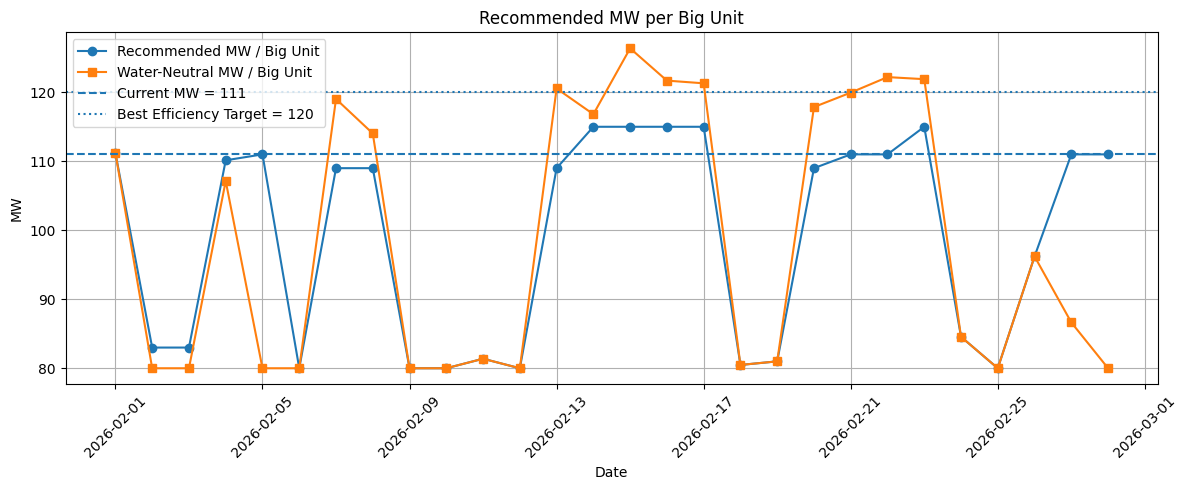

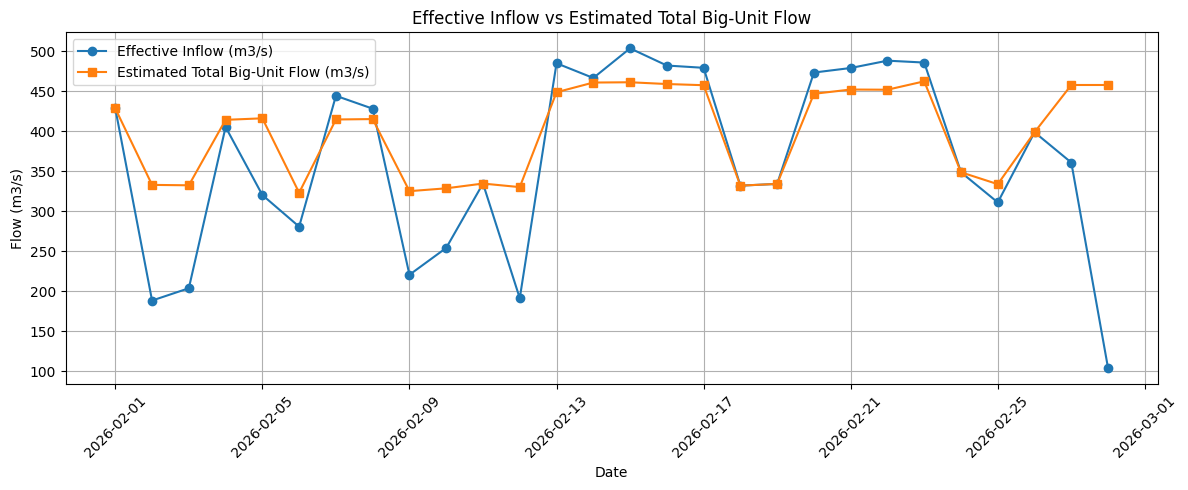

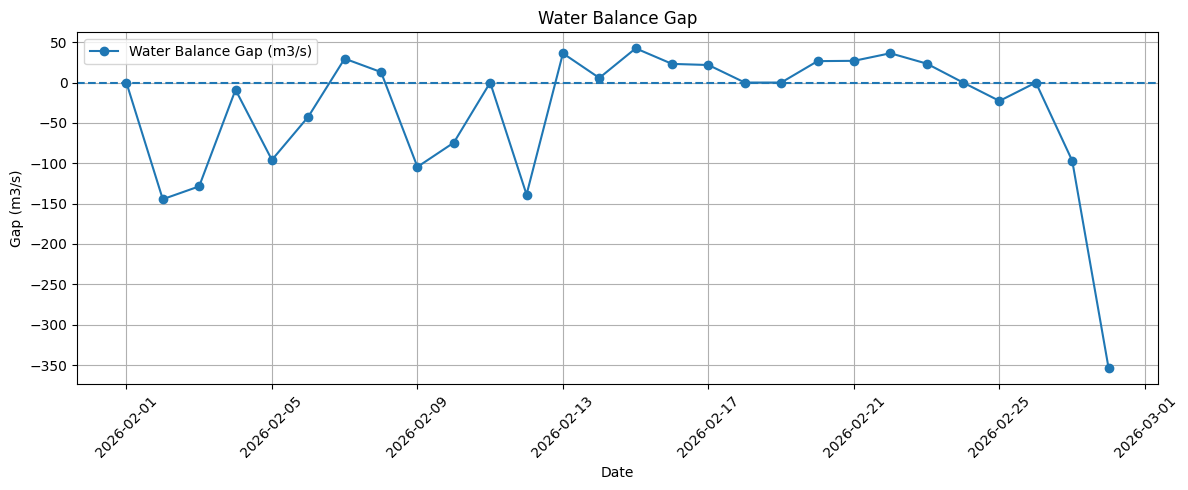

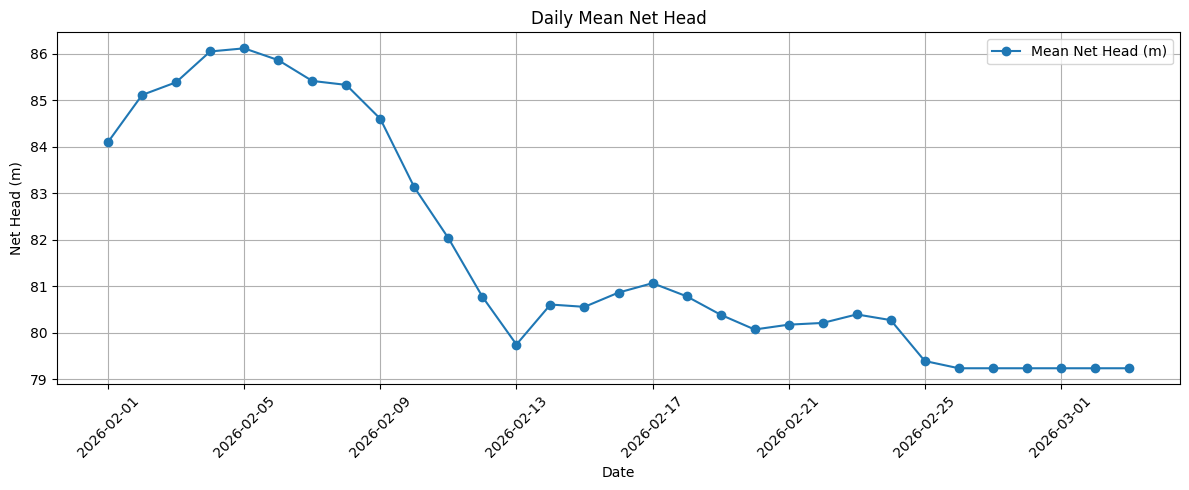

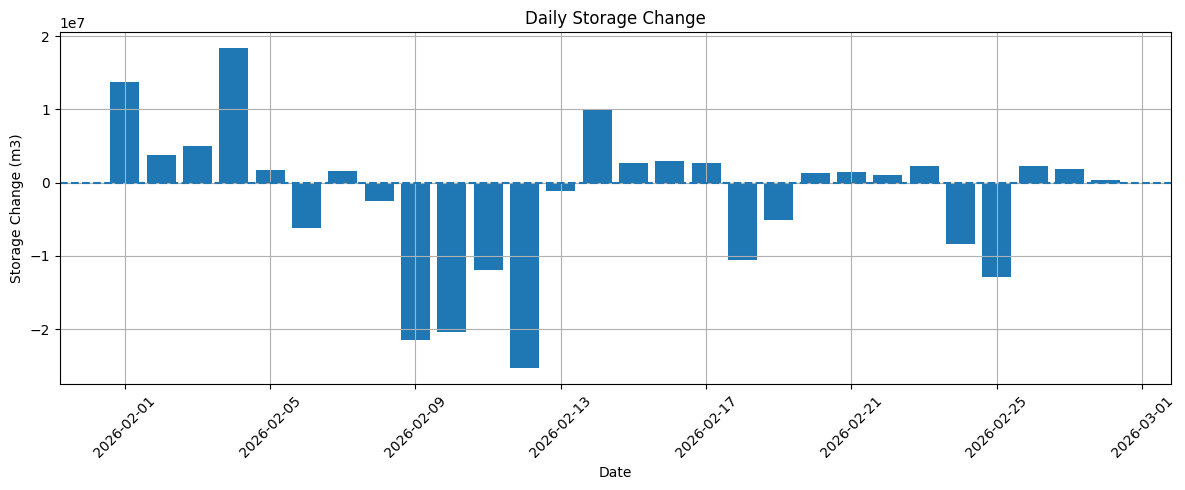

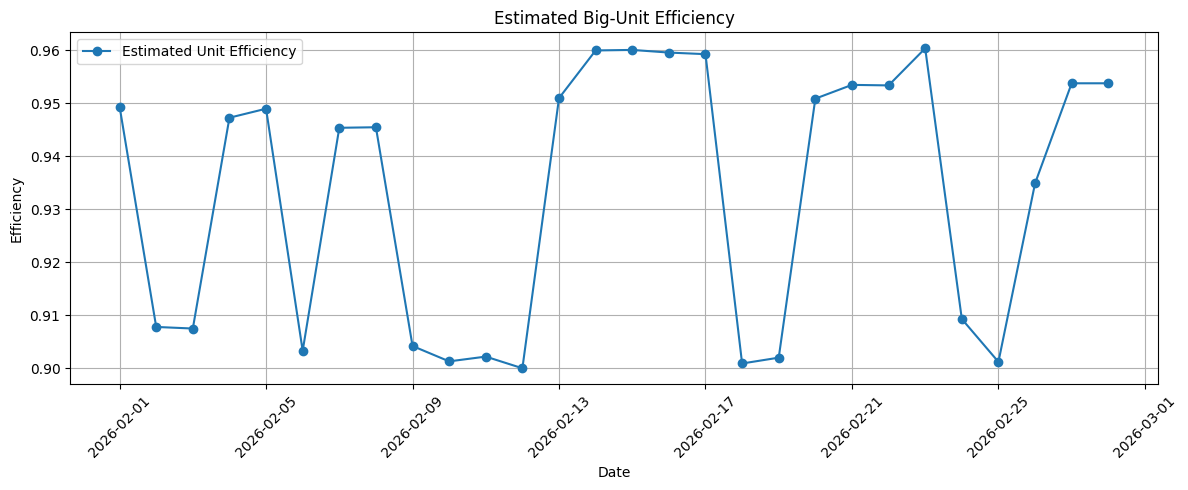

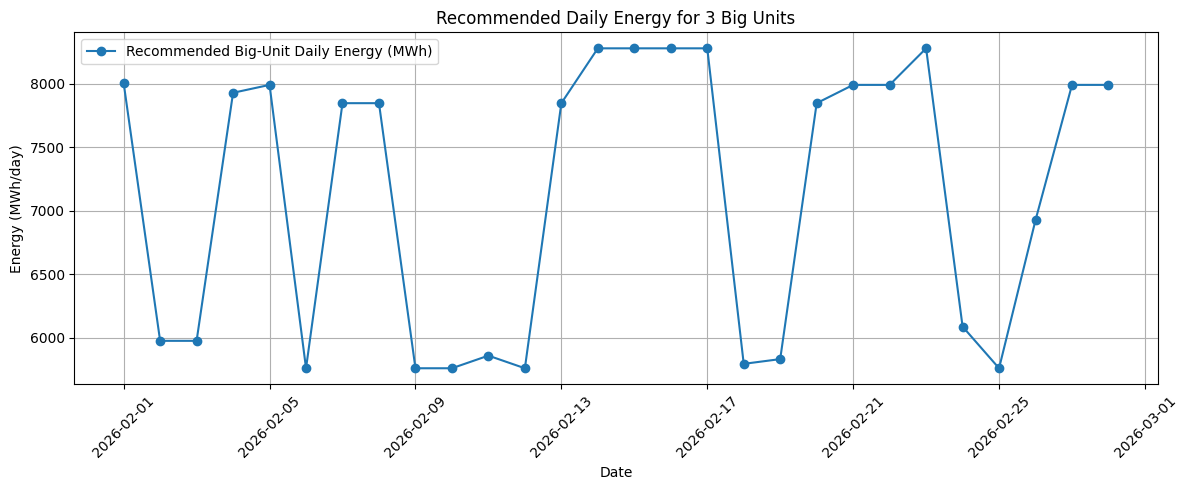

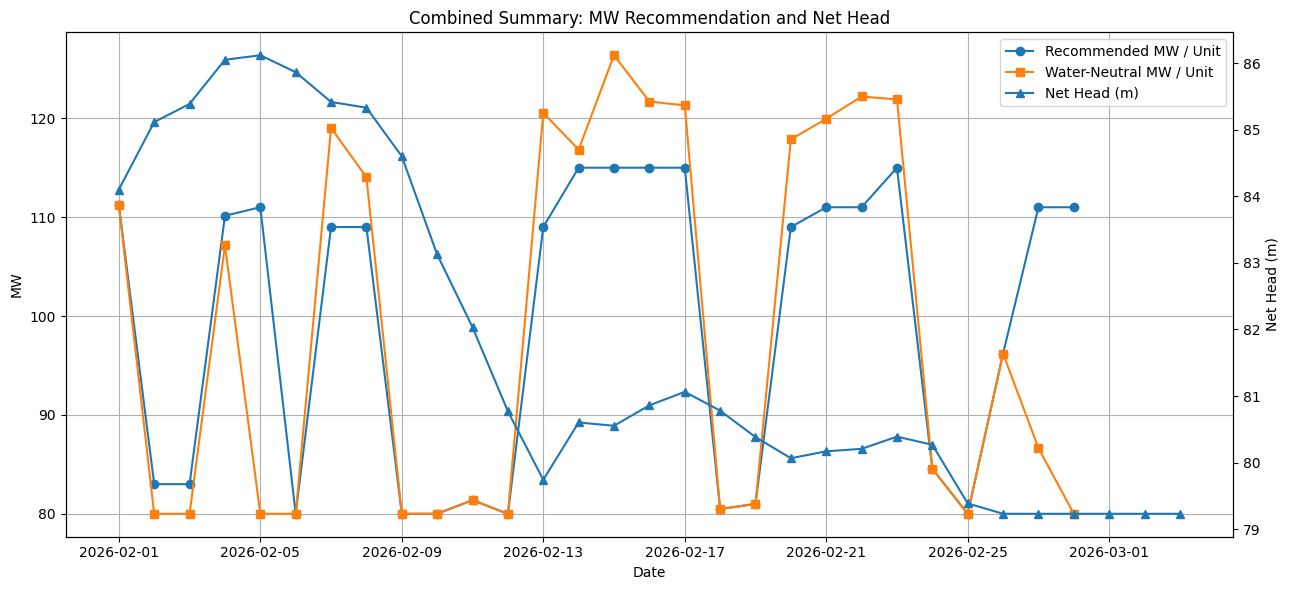


Charts saved in folder: hydro_plots


In [6]:
import os
import matplotlib.pyplot as plt

# =========================================================
# 10) PLOTS AND CHARTS
# =========================================================
plot_dir = "hydro_plots"
os.makedirs(plot_dir, exist_ok=True)

# Make sure date is datetime
result["date"] = pd.to_datetime(result["date"])

# -------------------------
# Plot 1: Recommended MW per big unit
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(result["date"], result["recommended_mw_per_big_unit"], marker="o", label="Recommended MW / Big Unit")
plt.plot(result["date"], result["water_neutral_unit_mw"], marker="s", label="Water-Neutral MW / Big Unit")
plt.axhline(111, linestyle="--", label="Current MW = 111")
plt.axhline(120, linestyle=":", label="Best Efficiency Target = 120")
plt.title("Recommended MW per Big Unit")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "01_recommended_mw_per_big_unit.png"), dpi=200)
plt.show()

# -------------------------
# Plot 2: Inflow vs Estimated Total Big-Unit Flow
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(result["date"], result["effective_inflow_m3s"], marker="o", label="Effective Inflow (m3/s)")
plt.plot(result["date"], result["estimated_total_big_flow_m3s"], marker="s", label="Estimated Total Big-Unit Flow (m3/s)")
plt.title("Effective Inflow vs Estimated Total Big-Unit Flow")
plt.xlabel("Date")
plt.ylabel("Flow (m3/s)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "02_inflow_vs_bigunit_flow.png"), dpi=200)
plt.show()

# -------------------------
# Plot 3: Water Balance Gap
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(result["date"], result["water_balance_gap_m3s"], marker="o", label="Water Balance Gap (m3/s)")
plt.axhline(0, linestyle="--")
plt.title("Water Balance Gap")
plt.xlabel("Date")
plt.ylabel("Gap (m3/s)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "03_water_balance_gap.png"), dpi=200)
plt.show()

# -------------------------
# Plot 4: Net Head Trend
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(result["date"], result["net_head_mean_m"], marker="o", label="Mean Net Head (m)")
plt.title("Daily Mean Net Head")
plt.xlabel("Date")
plt.ylabel("Net Head (m)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "04_net_head_trend.png"), dpi=200)
plt.show()

# -------------------------
# Plot 5: Storage Change
# -------------------------
plt.figure(figsize=(12, 5))
plt.bar(result["date"], result["storage_change_m3"])
plt.axhline(0, linestyle="--")
plt.title("Daily Storage Change")
plt.xlabel("Date")
plt.ylabel("Storage Change (m3)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "05_storage_change.png"), dpi=200)
plt.show()

# -------------------------
# Plot 6: Estimated Unit Efficiency
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(result["date"], result["estimated_unit_efficiency"], marker="o", label="Estimated Unit Efficiency")
plt.title("Estimated Big-Unit Efficiency")
plt.xlabel("Date")
plt.ylabel("Efficiency")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "06_estimated_efficiency.png"), dpi=200)
plt.show()

# -------------------------
# Plot 7: Recommended Daily Big-Unit Energy
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(result["date"], result["recommended_big_daily_mwh"], marker="o", label="Recommended Big-Unit Daily Energy (MWh)")
plt.title("Recommended Daily Energy for 3 Big Units")
plt.xlabel("Date")
plt.ylabel("Energy (MWh/day)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "07_recommended_daily_energy.png"), dpi=200)
plt.show()

# -------------------------
# Plot 8: Estimated Opening
# -------------------------
if "estimated_opening_pct" in result.columns and result["estimated_opening_pct"].notna().any():
    plt.figure(figsize=(12, 5))
    plt.plot(result["date"], result["estimated_opening_pct"], marker="o", label="Estimated Opening (%)")
    plt.title("Estimated Opening from Hill Chart")
    plt.xlabel("Date")
    plt.ylabel("Opening (%)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "08_estimated_opening.png"), dpi=200)
    plt.show()

# -------------------------
# Plot 9: Combined Summary Chart
# -------------------------
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(result["date"], result["recommended_mw_per_big_unit"], marker="o", label="Recommended MW / Unit")
ax1.plot(result["date"], result["water_neutral_unit_mw"], marker="s", label="Water-Neutral MW / Unit")
ax1.set_xlabel("Date")
ax1.set_ylabel("MW")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(result["date"], result["net_head_mean_m"], marker="^", label="Net Head (m)")
ax2.set_ylabel("Net Head (m)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Combined Summary: MW Recommendation and Net Head")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "09_combined_summary.png"), dpi=200)
plt.show()

print(f"\nCharts saved in folder: {plot_dir}")